# AG-HYPOPT · Trial 25

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-four trials are registered; cell 2 reports `phase = trials` (24/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074). Picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_21 (0.1074, best):** travel 0.138, `lr_gamma=0.4716`, `gamma_anneal=0.4723` (balanced). 0 div.
- **trial_22 (0.1095):** travel 0.137. 0 div.
- **trial_08 (0.1099), trial_15 (0.1103), trial_24 (0.1108), trial_16 (0.1112), trial_12 (0.1115), trial_18 (0.1121):** travels 0.134 / 0.127 / 0.133 / 0.128 / 0.128 / 0.138; 0 div.
- rest: trial_09 = trial_20 0.1126, trial_01 = trial_14 = trial_23 0.1127, trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_06 0.1188.
- diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

State of play: the best region is a narrow spike at travel ~0.137-0.138 with balanced gamma knobs (`lr_gamma`~`gamma_anneal`~0.47); trial_21 (0.1074) leads, trial_22 (0.1095) is the closest neighbour. Five runs now sit below 0.111. Low travel (<0.10) is worse and the source of sporadic divergences. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_25'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (24/5 trials)
ID |     ei | params
 1 | 3.7665 | {"gamma_anneal": 0.4722086346676, "lr_gamma": 0.4503996595511184, "lr_mu": 0.10057602578196256, "mu_anneal": 0.34863134417411823}
 2 | 3.4425 | {"gamma_anneal": 0.20319418368912096, "lr_gamma": 0.4489294664321385, "lr_mu": 0.16324537501896638, "mu_anneal": 0.3515300805788521}
 3 | 3.9169 | {"gamma_anneal": 0.5242496357697499, "lr_gamma": 0.46649903214266486, "lr_mu": 0.16661102060140487, "mu_anneal": 0.3513506553556998}
 4 | 3.2955 | {"gamma_anneal": 0.4532090899612785, "lr_gamma": 0.40277693029086664, "lr_mu": 0.1695260560468388, "mu_anneal": 0.3532067666023598}
 5 | 1.9952 | {"gamma_anneal": 0.5354827297611493, "lr_gamma": 0.14255116146849928, "lr_mu": 0.16127798486819564, "mu_anneal": 0.9273024797593514}
 6 | 2.2799 | {"gamma_anneal": 0.5688520581662201, "lr_gamma": 0.4566218051536388, "lr_mu": 0.1822560822662194, "mu_anneal": 0.3512577287669344}
 7 | 2.2901 | {"gamma_anneal": 0.481714219122975, "lr_gamma": 0.940682937

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (24 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 3: **ei 3.92** — `lr_mu=0.167`, `mu_anneal=0.351` (travel **0.137**), `lr_gamma=0.466`, `gamma_anneal=0.524`.
- candidate 1: ei 3.77 — `lr_mu=0.101`, `mu_anneal=0.349` (travel 0.083, low), `lr_gamma=0.450`, `gamma_anneal=0.472`.
- candidate 2: ei 3.44 — `lr_mu=0.163`, `mu_anneal=0.352` (travel 0.135), `lr_gamma=0.449`, `gamma_anneal=0.203` (low).
- candidate 4: ei 3.30 — `lr_mu=0.170`, `mu_anneal=0.353` (travel 0.140), `lr_gamma=0.403`, `gamma_anneal=0.453`.
- candidate 6: ei 2.28 — `lr_mu=0.182`, `mu_anneal=0.351` (travel 0.150), `lr_gamma=0.457`.

Candidate 3 has the highest ei and sits exactly on the best point: travel 0.137 (trial_21's 0.138, trial_22's 0.137), with `lr_gamma=0.466`/`gamma_anneal=0.524` close to the balanced schedule that produced the best. It is the most direct resample of the best region. Candidates 2 and 4 are nearby but carry untested low `gamma_anneal` (0.203) or low `lr_gamma` (0.403); candidate 1 is low-travel. So the maximum-ei candidate 3 is also the best-supported.

I choose candidate 3 (3 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5242496357697499, 'lr_gamma': 0.46649903214266486, 'lr_mu': 0.16661102060140487, 'mu_anneal': 0.3513506553556998}
Running  1nW Trans05 ... 

μ 9.39 -> 10.31 | γ 8.5 -> 4.46 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 46.58 | γ 8.5 -> 6.20 | NLL 5.53


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 78.85 | γ 14.1 -> 14.69 | NLL 3.64


Running 3nW Trans100 ... 

μ 175.71 -> 111.28 | γ 14.1 -> 14.22 | NLL 3.47



Total: 9.7 min


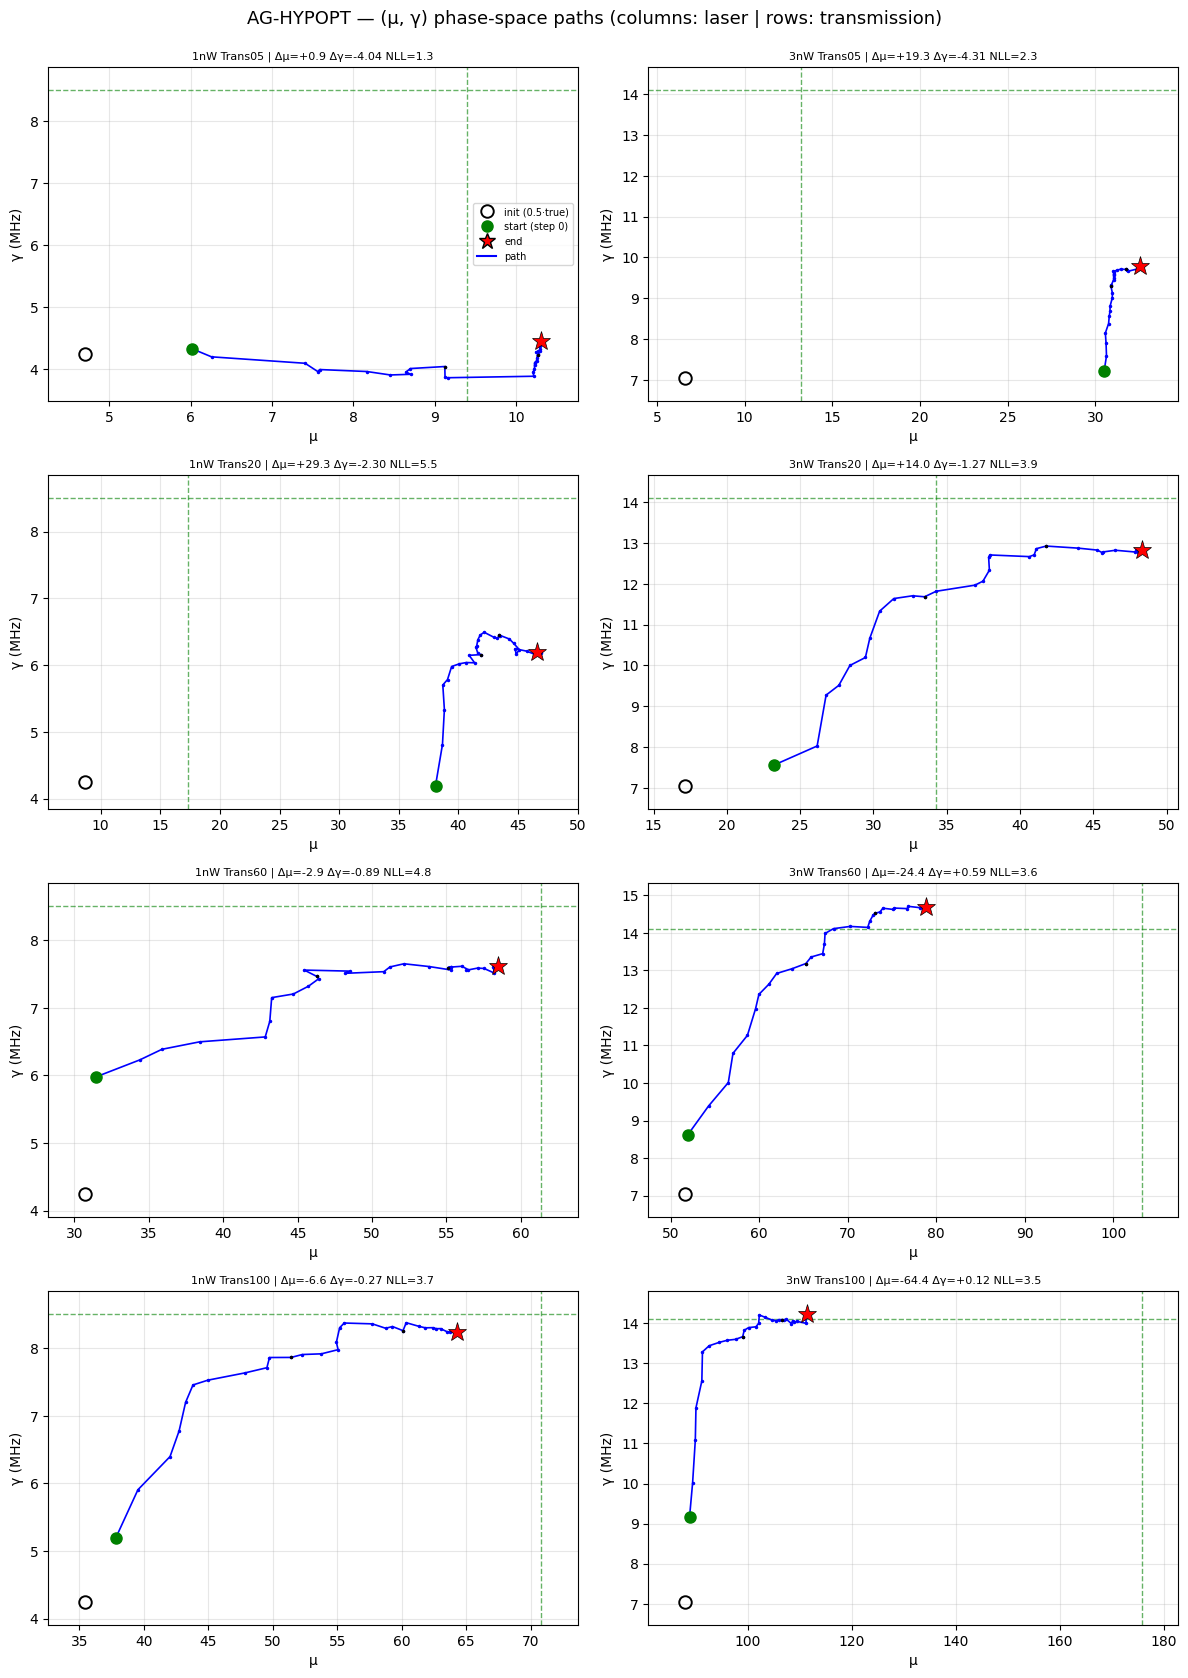

trial finished in 9.7 min
objective = 0.1126 ± 0.0823
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.31    +9.8 |     8.50    4.46   -47.5
1nW Trans20       17.32   46.58  +169.0 |     8.50    6.20   -27.1
1nW Trans60       61.37   58.47    -4.7 |     8.50    7.61   -10.4
1nW Trans100       70.82   64.24    -9.3 |     8.50    8.23    -3.2
3nW Trans05       13.20   32.53  +146.3 |    14.10    9.79   -30.6
3nW Trans20       34.28   48.29   +40.9 |    14.10   12.83    -9.0
3nW Trans60      103.20   78.85   -23.6 |    14.10   14.69    +4.2
3nW Trans100      175.71  111.28   -36.7 |    14.10   14.22    +0.9

weighted objective (T-graded, cap=1.0) = 0.1126 | diverged cells: 0
μ: RMSE 27.890 (rel 82.0%, bias -4.341) | γ: RMSE 2.319 (rel 22.8%, bias -1.546)


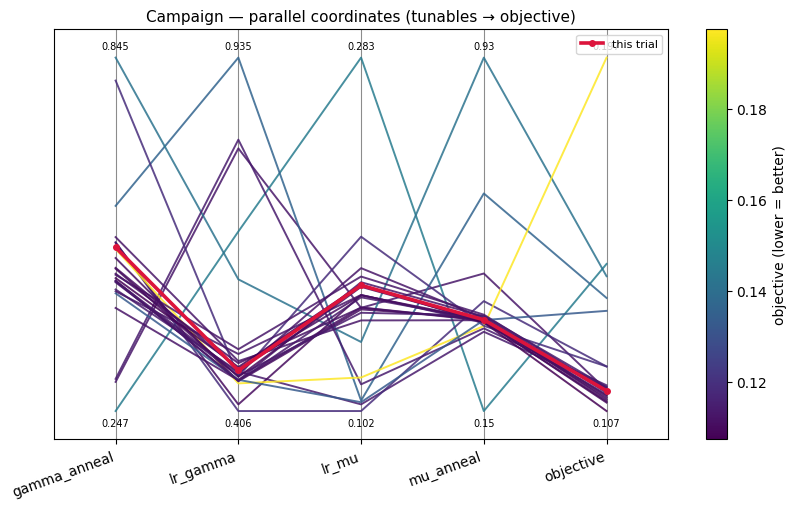

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 25 ran the highest-EI candidate (candidate 3, ei=3.92): `lr_mu=0.1666`, `mu_anneal=0.3514` (effective mu travel 0.137), `lr_gamma=0.4665`, `gamma_anneal=0.5242`. It completed in 9.7 min with objective **0.1126 +/- 0.0823** and **0 diverged cells** — mid-plateau. Ranking: trial_21 0.1074 < trial_22 0.1095 < trial_08 0.1099 < trial_15 0.1103 < trial_24 0.1108 < trial_16 0.1112 < trial_12 0.1115 < trial_18 0.1121 < trial_09 = trial_20 = **trial_25 0.1126** < ...

Aggregate accuracy: **mu rel-RMSE 82.0%** (RMSE 27.89, bias -4.34); **gamma rel-RMSE 22.8%** (RMSE 2.32, bias -1.55).

Per-cell relative errors:
- **mu:** 1nW T05 +9.8%, T20 +169.0%, T60 -4.7%, T100 -9.3% | 3nW T05 +146.3%, T20 +40.9%, T60 -23.6%, T100 -36.7%.
- **gamma:** 1nW T05 -47.5%, T20 -27.1%, T60 -10.4%, T100 -3.2% | 3nW T05 -30.6%, T20 -9.0%, T60 +4.2%, T100 +0.9%.

This was a direct resample of the best travel (0.137, same as trial_22) but with slightly different gamma knobs (`gamma_anneal=0.524` vs trial_22's `0.488`), and it landed at 0.1126 rather than trial_22's 0.1095 or trial_21's 0.1074. The difference is again in a few small cells — 1nW T20 (+169.0% here vs trial_22's +148.1%) and 1nW T100 (-9.3% vs -7.9%) — while everything else is similar. This strongly suggests that within the best band the residual ~0.005 spread is a narrow-cell effect (or mild chaotic sensitivity), not a smooth function of the knobs: the true optimum is a narrow spike, and trial_21 (0.1074) remains the best.

**Summary:** Trial 25 (lr_mu=0.1666, mu_anneal=0.3514, lr_gamma=0.4665, gamma_anneal=0.5242): objective 0.1126 +/- 0.0823 with 0 diverged cells; a resample right at the best travel (0.137) landed mid-plateau (0.1126) rather than at 0.1074, so trial_21 remains the best.
**Key insight:** Resampling trial_22's exact travel (0.137) with slightly different gamma knobs gave 0.1126 instead of 0.1095, so the residual spread within the best band is a small-cell (1nW T20/T60) effect - the best point is narrow and possibly somewhat sensitive.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The best band (travel 0.127-0.138, balanced gamma) now has eight sub-0.113 samples with outcomes 0.1074-0.1127, and the variation is driven by individual cells rather than a smooth knob dependence. That points to a combination of a genuinely narrow optimum and mild run-to-run (deterministic but chaotic) sensitivity; further hyperparameter tuning has very low expected return. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 25 (lr_mu=0.1666, mu_anneal=0.3514, lr_gamma=0.4665, gamma_anneal=0.5242): objective 0.1126 +/- 0.0823 with 0 diverged cells; a resample right at the best travel (0.137) landed mid-plateau (0.1126) rather than at 0.1074, so trial_21 remains the best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Resampling trial_22's exact travel (0.137) with slightly different gamma knobs gave 0.1126 instead of 0.1095, so the residual spread within the best band is a small-cell (1nW T20/T60) effect - the best point is narrow and possibly somewhat sensitive"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_25 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_26.ipynb. Open it and follow its cells from the top.
